### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("titanic_dataset - titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


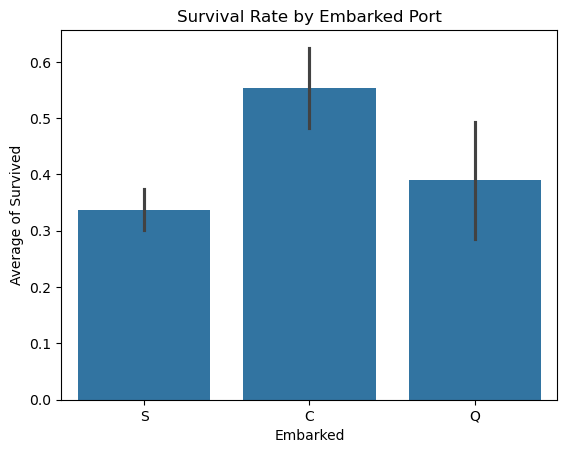

In [9]:
sns.barplot(data=df, x="Embarked", y="Survived")

plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Average of Survived")
plt.show()

In [10]:
df.groupby("Embarked")["Survived"].mean().idxmax()

'C'

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

In [12]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

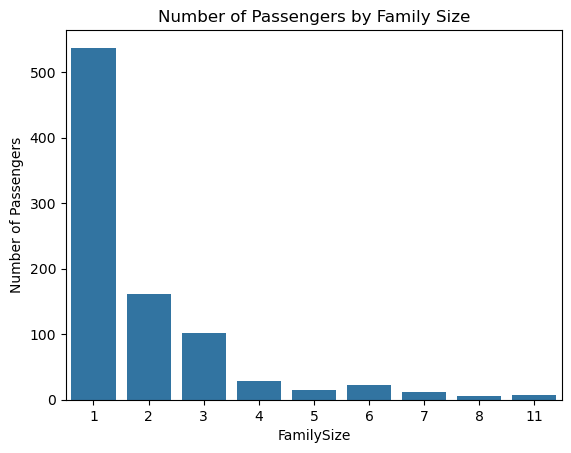

In [13]:
sns.countplot(data=df, x="FamilySize")

plt.title("Number of Passengers by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")
plt.show()

In [14]:
df["FamilySize"].value_counts().idxmax()

np.int64(1)

In [15]:
df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

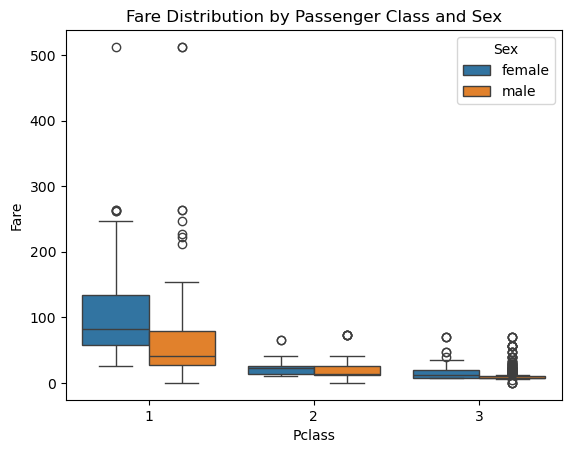

In [16]:
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Sex")

plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

In [17]:
df.groupby(["Pclass", "Sex"])["Fare"].max()

Pclass  Sex   
1       female    512.3292
        male      512.3292
2       female     65.0000
        male       73.5000
3       female     69.5500
        male       69.5500
Name: Fare, dtype: float64

In [18]:
df.groupby(["Pclass", "Sex"])["Fare"].max().idxmax()

(np.int64(1), 'female')

In [19]:
df.groupby(["Pclass", "Sex"])["Fare"].max().max()

512.3292

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

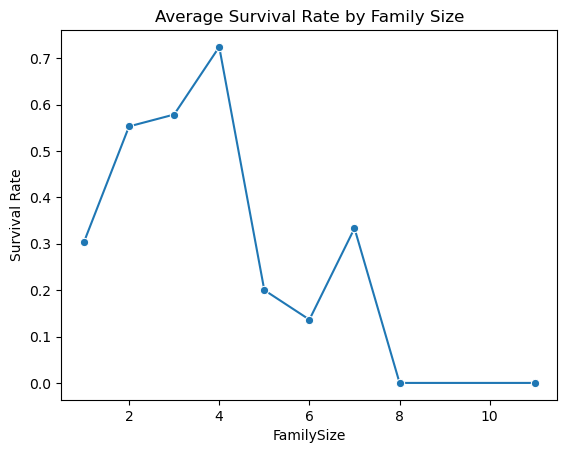

In [20]:
family_survival = df.groupby("FamilySize")["Survived"].mean()

sns.lineplot(
    x=family_survival.index,
    y=family_survival.values,
    marker="o"
)

plt.title("Average Survival Rate by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Survival Rate")
plt.show()

In [21]:
df.groupby("FamilySize")["Survived"].mean().idxmax()

np.int64(4)

In [22]:
df.groupby("FamilySize")["Survived"].mean().max()

0.7241379310344828

### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

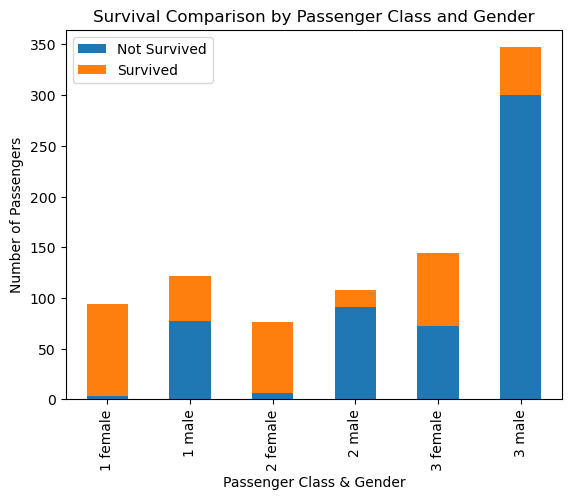

In [24]:
df["Pclass_Sex"] = df["Pclass"].astype(str) + " " + df["Sex"]

survival_table = pd.crosstab(
    df["Pclass_Sex"],
    df["Survived"]
)

survival_table.columns = ["Not Survived", "Survived"]

survival_table.plot(kind="bar", stacked=True)

plt.title("Survival Comparison by Passenger Class and Gender")
plt.xlabel("Passenger Class & Gender")
plt.ylabel("Number of Passengers")
plt.show()